In [ ]:
from google.colab import files
uploaded = files.upload()


Saving vast_english_french.txt to vast_english_french.txt


In [ ]:
import re
import random
import math
import time
import unicodedata
from io import open

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
PAD_token = 0
SOS_token = 1
EOS_token = 2

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "PAD", 1: "SOS", 2: "EOS"}
        self.n_words = 3

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1


def normalize_string(s, is_french=False):
    s = s.strip()
    if not is_french:
        s = ''.join(
            c for c in unicodedata.normalize('NFD', s.lower())
            if unicodedata.category(c) != 'Mn'
        )
    else:
        s = s.lower()
    s = re.sub(r"([.!?,])", r" \1", s)
    s = re.sub(r"[^a-zA-Z0-9àâäéèêëïîôöùûüç.!?,'\- ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def read_data(path):
    lines = open(path, encoding='utf-8').read().strip().split('\n')
    pairs = []
    for line in lines:
        if not line.strip():
            continue
        parts = line.split('\t')
        if len(parts) < 2:
            continue
        eng, fra = parts[0], parts[1]
        pairs.append([normalize_string(eng, is_french=False),
                       normalize_string(fra, is_french=True)])
    return pairs


DATA_PATH = "vast_english_french.txt"
pairs = read_data(DATA_PATH)

MAX_LENGTH = 20
pairs = [p for p in pairs if len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH]
print(f"{len(pairs)} pairs after length filtering")

input_lang = Lang("eng")
output_lang = Lang("fra")

for eng, fra in pairs:
    input_lang.add_sentence(eng)
    output_lang.add_sentence(fra)

print(f"English vocabulary size: {input_lang.n_words}")
print(f"French vocabulary size: {output_lang.n_words}")

random.shuffle(pairs)
split_idx = int(0.8 * len(pairs))
train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]
print(f"Training pairs: {len(train_pairs)} | Validation pairs: {len(val_pairs)}")


555 pairs after length filtering
English vocabulary size: 1016
French vocabulary size: 1138
Training pairs: 444 | Validation pairs: 111


In [ ]:
def tensor_from_sentence(lang, sentence):
    indexes = [lang.word2index[w] for w in sentence.split(' ') if w in lang.word2index]
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)


def tensors_from_pair(pair):
    input_tensor = tensor_from_sentence(input_lang, pair[0])
    target_tensor = tensor_from_sentence(output_lang, pair[1])
    return input_tensor, target_tensor


In [ ]:
HIDDEN_SIZE = 256
DROPOUT = 0.3

class EncoderGRU(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input_tensor, hidden):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        embedded = self.dropout(embedded)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden

    def init_hidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)


class BahdanauAttention(nn.Module):

    def __init__(self, hidden_size):
        super().__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, decoder_hidden, encoder_outputs):

        decoder_hidden_t = decoder_hidden.permute(1, 0, 2)
        scores = self.Va(torch.tanh(self.Wa(decoder_hidden_t) + self.Ua(encoder_outputs.permute(1, 0, 2))))
        scores = scores.squeeze(2)
        attn_weights = F.softmax(scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs.permute(1, 0, 2))
        return context, attn_weights


class AttnDecoderGRU(nn.Module):
    def __init__(self, hidden_size, output_size, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(hidden_size * 2, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward(self, input_tensor, hidden, encoder_outputs):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        embedded = self.dropout(embedded)

        context, attn_weights = self.attention(hidden, encoder_outputs)

        gru_input = torch.cat((embedded, context.permute(1, 0, 2)), dim=2)

        output, hidden = self.gru(gru_input, hidden)

        output = self.log_softmax(self.out(output[0]))

        return output, hidden, attn_weights


In [ ]:
TEACHER_FORCING_RATIO = 0.5

def train_step(input_tensor, target_tensor, encoder, decoder,
                encoder_optimizer, decoder_optimizer, criterion):
    encoder_hidden = encoder.init_hidden()
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    encoder_outputs = torch.zeros(MAX_LENGTH, 1, encoder.hidden_size, device=device)
    encoder_outputs_list = []
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        encoder_outputs_list.append(encoder_output)
    encoder_outputs_cat = torch.cat(encoder_outputs_list, dim=0)

    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden

    loss = 0
    use_teacher_forcing = random.random() < TEACHER_FORCING_RATIO

    if use_teacher_forcing:
        for di in range(target_length):
            decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs_cat)
            loss += criterion(decoder_output, target_tensor[di])
            decoder_input = target_tensor[di]
    else:
        for di in range(target_length):
            decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs_cat)
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach().view(1, 1)
            loss += criterion(decoder_output, target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

    loss.backward()
    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length


def evaluate_loss(input_tensor, target_tensor, encoder, decoder, criterion):
    with torch.no_grad():
        encoder_hidden = encoder.init_hidden()
        input_length = input_tensor.size(0)
        target_length = target_tensor.size(0)

        encoder_outputs_list = []
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs_list.append(encoder_output)
        encoder_outputs_cat = torch.cat(encoder_outputs_list, dim=0)

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        loss = 0
        for di in range(target_length):
            decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs_cat)
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach().view(1, 1)
            loss += criterion(decoder_output, target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

        return loss.item() / target_length


In [ ]:
def run_training(encoder, decoder, n_epochs, learning_rate=0.01):
    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    train_tensors = [tensors_from_pair(p) for p in train_pairs]
    val_tensors = [tensors_from_pair(p) for p in val_pairs]

    train_losses, val_losses = [], []
    start = time.time()

    for epoch in range(1, n_epochs + 1):
        encoder.train()
        decoder.train()
        random.shuffle(train_tensors)
        total_train_loss = 0
        for input_tensor, target_tensor in train_tensors:
            total_train_loss += train_step(input_tensor, target_tensor, encoder,
                                            decoder, encoder_optimizer, decoder_optimizer, criterion)
        avg_train_loss = total_train_loss / len(train_tensors)

        encoder.eval()
        decoder.eval()
        total_val_loss = 0
        for input_tensor, target_tensor in val_tensors:
            total_val_loss += evaluate_loss(input_tensor, target_tensor, encoder, decoder, criterion)
        avg_val_loss = total_val_loss / len(val_tensors)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        elapsed = time.time() - start
        print(f"Epoch {epoch:3d}/{n_epochs} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Elapsed: {elapsed:.1f}s")

    return train_losses, val_losses


In [ ]:
N_EPOCHS = 10
LEARNING_RATE = 0.01

encoder = EncoderGRU(input_lang.n_words, HIDDEN_SIZE, DROPOUT).to(device)
attn_decoder = AttnDecoderGRU(HIDDEN_SIZE, output_lang.n_words, DROPOUT).to(device)

train_losses, val_losses = run_training(encoder, attn_decoder, N_EPOCHS, LEARNING_RATE)


Epoch   1/10 | Train Loss: 4.5802 | Val Loss: 3.1415 | Elapsed: 3.5s
Epoch   2/10 | Train Loss: 4.2698 | Val Loss: 3.8792 | Elapsed: 6.4s
Epoch   3/10 | Train Loss: 4.0391 | Val Loss: 4.4458 | Elapsed: 9.3s
Epoch   4/10 | Train Loss: 3.7796 | Val Loss: 3.4991 | Elapsed: 12.2s
Epoch   5/10 | Train Loss: 3.4753 | Val Loss: 3.9928 | Elapsed: 15.2s
Epoch   6/10 | Train Loss: 3.1948 | Val Loss: 4.5147 | Elapsed: 18.1s
Epoch   7/10 | Train Loss: 2.9744 | Val Loss: 3.2759 | Elapsed: 21.1s
Epoch   8/10 | Train Loss: 2.7313 | Val Loss: 3.6396 | Elapsed: 24.1s
Epoch   9/10 | Train Loss: 2.5513 | Val Loss: 3.8155 | Elapsed: 27.2s
Epoch  10/10 | Train Loss: 2.3033 | Val Loss: 3.7238 | Elapsed: 30.2s


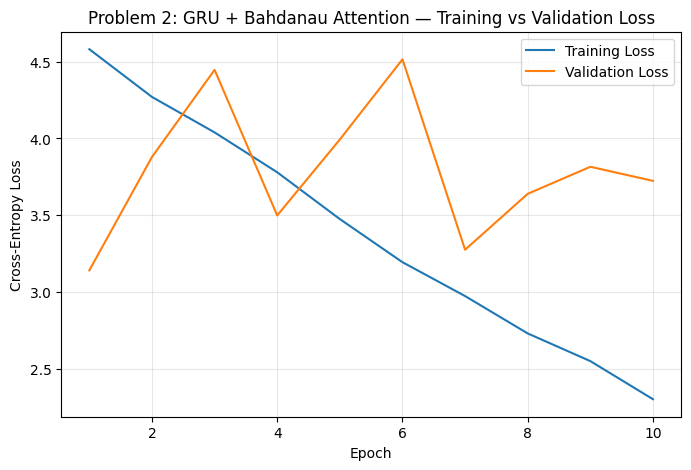

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="Training Loss")
plt.plot(range(1, N_EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 2: GRU + Bahdanau Attention — Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("problem2_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

smoothie = SmoothingFunction().method4

def evaluate_sentence(encoder, decoder, sentence, max_length=MAX_LENGTH):
    with torch.no_grad():
        input_tensor = tensor_from_sentence(input_lang, sentence)
        input_length = input_tensor.size(0)
        encoder_hidden = encoder.init_hidden()

        encoder_outputs_list = []
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs_list.append(encoder_output)
        encoder_outputs_cat = torch.cat(encoder_outputs_list, dim=0)

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        decoded_words = []
        attentions = []
        for di in range(max_length):
            decoder_output, decoder_hidden, attn_weights = decoder(decoder_input, decoder_hidden, encoder_outputs_cat)
            attentions.append(attn_weights.squeeze(0).cpu().numpy())
            topv, topi = decoder_output.topk(1)
            if topi.item() == EOS_token:
                break
            else:
                decoded_words.append(output_lang.index2word[topi.item()])
            decoder_input = topi.squeeze().detach().view(1, 1)

        return decoded_words, attentions


def evaluate_full_validation_set(encoder, decoder, val_pairs):
    encoder.eval()
    decoder.eval()
    exact_matches = 0
    bleu_scores = []
    results = []

    for eng, fra in val_pairs:
        predicted_words, _ = evaluate_sentence(encoder, decoder, eng)
        predicted_sentence = ' '.join(predicted_words)
        reference_words = fra.split(' ')

        is_exact_match = (predicted_words == reference_words)
        if is_exact_match:
            exact_matches += 1

        bleu = sentence_bleu([reference_words], predicted_words,
                              weights=(0.25, 0.25, 0.25, 0.25),
                              smoothing_function=smoothie)
        bleu_scores.append(bleu)

        results.append({
            "source": eng, "reference": fra, "predicted": predicted_sentence,
            "exact_match": is_exact_match, "bleu": bleu
        })

    exact_match_accuracy = exact_matches / len(val_pairs)
    avg_bleu = sum(bleu_scores) / len(bleu_scores)
    return exact_match_accuracy, avg_bleu, results


exact_match_accuracy, avg_bleu, val_results = evaluate_full_validation_set(encoder, attn_decoder, val_pairs)
print(f"Validation Exact Sequence Match Accuracy: {exact_match_accuracy * 100:.2f}%")
print(f"Validation BLEU-4 Score: {avg_bleu:.4f}")


Validation Exact Sequence Match Accuracy: 0.00%
Validation BLEU-4 Score: 0.0820


Sample 1
  Source:    the birds are building a nest
  Reference: les oiseaux construisent un nid
  Predicted: nous avons visité une grande ville


/tmp/ipykernel_743/1799564433.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  attentions = torch.tensor(attentions)[: len(output_words)]


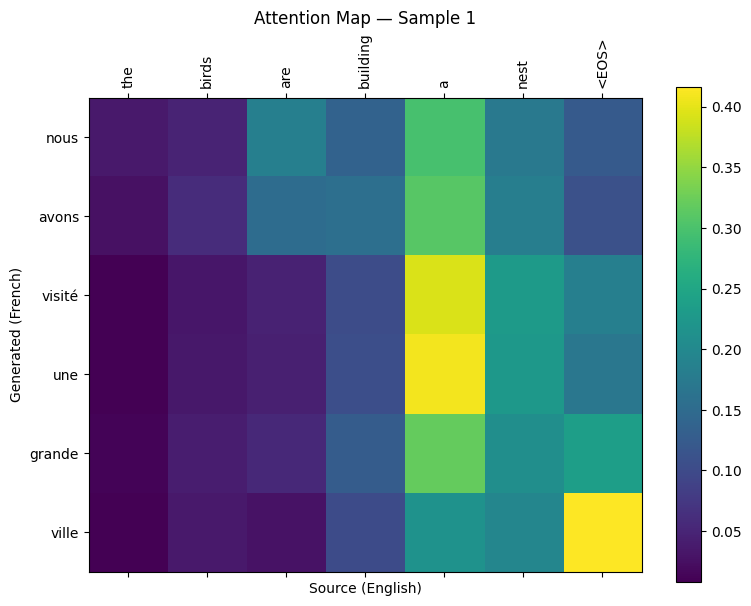

Sample 2
  Source:    we swim during summer
  Reference: nous nageons pendant l'été
  Predicted: nous avons visité les ruines


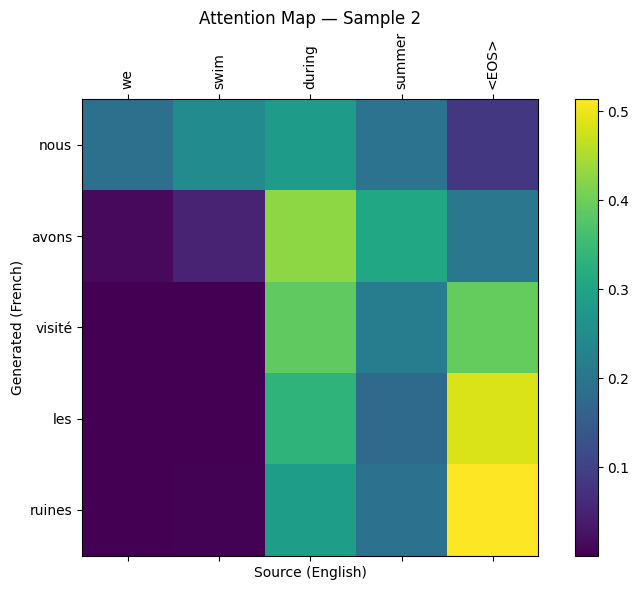

In [ ]:
def plot_attention(input_sentence, output_words, attentions, title="Attention Map"):
    attentions = torch.tensor(attentions)[: len(output_words)]
    fig, ax = plt.subplots(figsize=(8, 6))
    cax = ax.matshow(attentions.numpy(), cmap='viridis')
    fig.colorbar(cax)

    input_words = input_sentence.split(' ') + ['<EOS>']
    ax.set_xticks(range(len(input_words)))
    ax.set_xticklabels(input_words, rotation=90)
    ax.set_yticks(range(len(output_words)))
    ax.set_yticklabels(output_words)
    ax.set_xlabel("Source (English)")
    ax.set_ylabel("Generated (French)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


random.seed(11)
attn_samples = random.sample(val_pairs, 2)

for i, (eng, fra) in enumerate(attn_samples, 1):
    predicted_words, attentions = evaluate_sentence(encoder, attn_decoder, eng)
    print(f"Sample {i}")
    print(f"  Source:    {eng}")
    print(f"  Reference: {fra}")
    print(f"  Predicted: {' '.join(predicted_words)}")
    plot_attention(eng, predicted_words, attentions, title=f"Attention Map — Sample {i}")


In [ ]:
random.seed(7)
sample_results = random.sample(val_results, 5)


for i, r in enumerate(sample_results, 1):
    print(f"Sample {i}")
    print(f"  English (source):     {r['source']}")
    print(f"  Reference (target):   {r['reference']}")
    print(f"  Predicted:            {r['predicted']}")
    print(f"  Exact Match:          {r['exact_match']}")
    print(f"  BLEU-4 Score:         {r['bleu']:.4f}")



Sample 1
  English (source):     he speaks six international languages completely fluently
  Reference (target):   il parle couramment six langues internationales
  Predicted:            il parle couramment cinq langues
  Exact Match:          False
  BLEU-4 Score:         0.2635
Sample 2
  English (source):     he vacuums his entire house every friday afternoon
  Reference (target):   il passe l'aspirateur dans toute sa maison tous les vendredis après-midi
  Predicted:            il conduit de la chaque après-midi
  Exact Match:          False
  BLEU-4 Score:         0.0194
Sample 3
  English (source):     they constructed a large stone wall around the property
  Reference (target):   ils ont construit un grand mur de pierre autour de la propriété
  Predicted:            ils ont construit une grande ville
  Exact Match:          False
  BLEU-4 Score:         0.0860
Sample 4
  English (source):     i see a plane in the sky
  Reference (target):   je vois un avion dans le ciel
  Predict